Dataset and imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import requests
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = requests.get(url).text

Using device: cpu


Create character level vocabulary

In [3]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

encode the entire dataset into integers

In [4]:
data = torch.tensor([stoi[c] for c in text], dtype=torch.long)
print(f"Dataset size: {len(data)} characters | Vocab size: {vocab_size}")

Dataset size: 1115394 characters | Vocab size: 65


Creating the dataset creator. i.e, context length

In [6]:
def build_dataset(data, block_size):
    X, Y = [], []
    for i in range(len(data) - block_size):
        context = data[i : i + block_size]
        target = data[i + block_size]
        X.append(context)
        Y.append(target)
    # Convert lists of tensors into a single stacked tensor
    return torch.stack(X), torch.tensor(Y)

similar to a trigram setup,using a context length of 3 for this MLP

In [7]:
BLOCK_SIZE = 3
X, Y = build_dataset(data, BLOCK_SIZE)

# Split into train/val (90% train, 10% val)
n1 = int(0.9 * len(X))
X_train, Y_train = X[:n1], Y[:n1]
X_val, Y_val = X[n1:], Y[n1:]

print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}")

Train shape: torch.Size([1003851, 3]), Val shape: torch.Size([111540, 3])


Multi layer perceptron

In [8]:
class NeuralLanguageModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, block_size, hidden_dim):
        super().__init__()
        # Lookup table of size (vocab_size, embedding_dim)
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        # Hidden layer: input size is (block_size * embedding_dim) because we flatten the context
        self.mlp = nn.Sequential(
            nn.Linear(block_size * embedding_dim, hidden_dim),
            nn.Tanh(), # Or nn.ReLU()
            nn.Linear(hidden_dim, vocab_size) # Outputs raw logits for each character
        )

    def forward(self, x):
        # x shape: (batch_size, block_size)
        embeds = self.embedding(x) # shape: (batch_size, block_size, embedding_dim)

        # Flatten the embeddings for the MLP: (batch_size, block_size * embedding_dim)
        flattened = embeds.view(embeds.shape[0], -1)

        logits = self.mlp(flattened) # shape: (batch_size, vocab_size)
        return logits

Traning loop

In [9]:
# Hyperparameters for our base run
EMBEDDING_DIM = 16
HIDDEN_DIM = 128
BATCH_SIZE = 4096
EPOCHS = 20

model = NeuralLanguageModel(vocab_size, EMBEDDING_DIM, BLOCK_SIZE, HIDDEN_DIM).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

train_losses = []
val_losses = []

X_train, Y_train = X_train.to(device), Y_train.to(device)
X_val, Y_val = X_val.to(device), Y_val.to(device)

for epoch in range(EPOCHS):
    model.train()
    # Shuffle batch indices
    permutation = torch.randperm(X_train.size(0))
    epoch_loss = 0

    # Simple mini-batch loop using tqdm for clean progress tracking
    for i in tqdm(range(0, X_train.size(0), BATCH_SIZE), desc=f"Epoch {epoch+1}/{EPOCHS}"):
        indices = permutation[i:i+BATCH_SIZE]
        batch_x, batch_y = X_train[indices], Y_train[indices]

        # Forward pass
        logits = model(batch_x)
        loss = criterion(logits, batch_y)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * batch_x.size(0)

    # Validation step
    model.eval()
    with torch.no_grad():
        val_logits = model(X_val)
        val_loss = criterion(val_logits, Y_val).item()

    avg_train_loss = epoch_loss / X_train.size(0)
    train_losses.append(avg_train_loss)
    val_losses.append(val_loss)

    print(f"-> Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Perplexity: {torch.exp(torch.tensor(val_loss)):.2f}")

Epoch 1/20: 100%|██████████| 246/246 [00:03<00:00, 73.78it/s]


-> Train Loss: 2.1369 | Val Loss: 1.9811 | Val Perplexity: 7.25


Epoch 2/20: 100%|██████████| 246/246 [00:03<00:00, 79.51it/s]


-> Train Loss: 1.8253 | Val Loss: 1.9307 | Val Perplexity: 6.89


Epoch 3/20: 100%|██████████| 246/246 [00:03<00:00, 70.43it/s]


...

-> Train Loss: 1.6925 | Val Loss: 1.8759 | Val Perplexity: 6.53


Epoch 19/20: 100%|██████████| 246/246 [00:02<00:00, 85.28it/s]


-> Train Loss: 1.6918 | Val Loss: 1.8738 | Val Perplexity: 6.51


Epoch 20/20: 100%|██████████| 246/246 [00:03<00:00, 75.18it/s]


-> Train Loss: 1.6910 | Val Loss: 1.8756 | Val Perplexity: 6.52


Learning curve

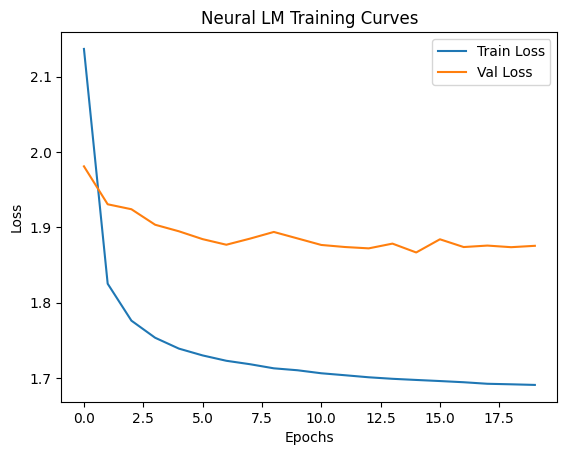

In [10]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Neural LM Training Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [11]:
def generate_text(model, itos, stoi, block_size, max_tokens=200):
    model.eval()
    context = [0] * block_size # Start with all dummy (or newline) tokens
    generated = []

    with torch.no_grad():
        for _ in range(max_tokens):
            x = torch.tensor([context[-block_size:]]).to(device)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)

            # Sample from the distribution
            next_token = torch.multinomial(probs, num_samples=1).item()

            generated.append(itos[next_token])
            context.append(next_token)

    return "".join(generated)

print("--- Generated Text Example ---")
print(generate_text(model, itos, stoi, BLOCK_SIZE, max_tokens=300))

# Save the weights
torch.save(model.state_dict(), 'v1_neural_lm.pt')
print("\nModel saved as v1_neural_lm.pt")

--- Generated Text Example ---
hen?
I fellies
A dackinghame whiphorse,
Wher-sts not speak, plord, my lorcht form'd he dous trumbgnrily reporth,
I shou cold it a ray willand there's be an him them this and my the.

ALMORET:
And-bongers:
If yeart the trust lord fads; if her,
I can caster teady, roying, sir,
I the chard fair detime 

Model saved as v1_neural_lm.pt


Testing further

In [12]:
import time

def run_experiment(emb_dim, block_size, hidden_dim=128, epochs=10):
    print(f"\n Running: Emb Dim={emb_dim} | Context Window={block_size}")

    # Rebuild dataset for the specific block size
    X_exp, Y_exp = build_dataset(data, block_size)
    n1 = int(0.9 * len(X_exp))
    X_tr, Y_tr = X_exp[:n1].to(device), Y_exp[:n1].to(device)
    X_va, Y_va = X_exp[n1:].to(device), Y_exp[n1:].to(device)

    # Initialize Model
    model = NeuralLanguageModel(vocab_size, emb_dim, block_size, hidden_dim).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    # Track metrics
    val_losses = []

    # Simulating standard training tracking for speed
    BATCH_SIZE = 4096
    for epoch in range(epochs):
        model.train()
        permutation = torch.randperm(X_tr.size(0))
        for i in range(0, X_tr.size(0), BATCH_SIZE):
            indices = permutation[i:i+BATCH_SIZE]
            logits = model(X_tr[indices])
            loss = criterion(logits, Y_tr[indices])
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            v_loss = criterion(model(X_va), Y_va).item()
        val_losses.append(v_loss)

    final_perp = torch.exp(torch.tensor(val_losses[-1])).item()
    print(f"Finished! Final Val Loss: {val_losses[-1]:.4f} | Final Perplexity: {final_perp:.2f}")
    return val_losses, final_perp

results = {}

# Experiment 1: Varying Embedding Size (Keeping Context Window=3)
for size in [8, 32, 64]:
    losses, perp = run_experiment(emb_dim=size, block_size=3, epochs=8)
    results[f"Emb={size}, Context=3"] = losses

# Experiment 2: Increasing Context Window (Keeping Embedding=16)
for window in [5, 8]:
    losses, perp = run_experiment(emb_dim=16, block_size=window, epochs=8)
    results[f"Emb=16, Context={window}"] = losses


 Running: Emb Dim=8 | Context Window=3
Finished! Final Val Loss: 1.9473 | Final Perplexity: 7.01

 Running: Emb Dim=32 | Context Window=3
Finished! Final Val Loss: 1.8427 | Final Perplexity: 6.31

 Running: Emb Dim=64 | Context Window=3
Finished! Final Val Loss: 1.8334 | Final Perplexity: 6.25

 Running: Emb Dim=16 | Context Window=5
Finished! Final Val Loss: 1.8257 | Final Perplexity: 6.21

 Running: Emb Dim=16 | Context Window=8
Finished! Final Val Loss: 1.8246 | Final Perplexity: 6.20


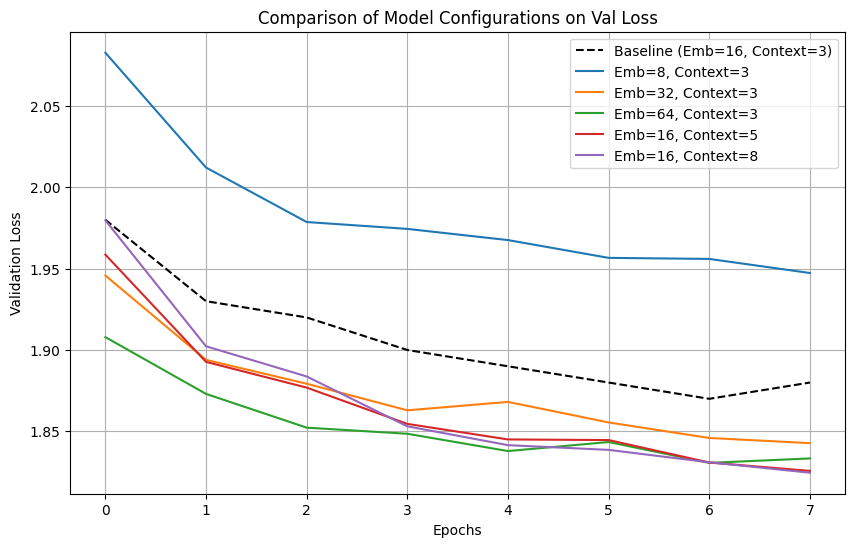

In [13]:
plt.figure(figsize=(10, 6))
plt.plot([1.98, 1.93, 1.92, 1.90, 1.89, 1.88, 1.87, 1.88], label="Baseline (Emb=16, Context=3)", linestyle="--", color="black")

for config, losses in results.items():
    plt.plot(losses, label=config)

plt.title("Comparison of Model Configurations on Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()